# Results Comparison

This notebook will evaluate and compare the performance of all of the models using Tensorboard and code-based metrics.


## Import Dependencies


In [2]:
import os
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import pickle

In [3]:
%matplotlib inline

## run tensorboard logging


In [4]:
# %load_ext tensorboard
# %tensorboard --logdir TensorBoard/runs --port 6006

## Read Events Files


### paths and defns


In [5]:
RUNS_DIR: Path = Path('TensorBoard/runs')


model_groups = {
    'YOLO': {
        'yolov8-amy': [],
        'yolov8-Joachim': [],
        'yolov11': [],
        'yolov12': []
    },
    'COCO': {
        'efficieentDet': [],
        'faster-rcnn': [],
        'rf-detr': [],
        'retina-net': []
    },
    'SIGN_ATTR': {
        'sign-condition': [],
        'sign-shape': [],
        'viewing-angle': [],
        'mounting-type': []
    }
}

In [6]:
# fn to load a single file
def extract_scalars_from_event(event_path, model_name, category) -> pd.DataFrame:
    """
    Read a single event file and returns a DataFrame of all scalar metrics.
    """
    # Load the event file with full size guidance
    ea = EventAccumulator(str(event_path), size_guidance={'scalars': 0})
    ea.Reload()
    
    scalar_tags = ea.Tags()['scalars']
    if not scalar_tags:
        return pd.DataFrame() # Return empty if no scalars found

    dfs = []
    
    # Extract data for every metric (tag) found in the file
    for tag in scalar_tags:
        events = ea.Scalars(tag)
        temp_df = pd.DataFrame(events)
        
        # Keep relevant columns and rename
        temp_df = temp_df[['step', 'value']]
        temp_df['metric'] = tag
        dfs.append(temp_df)
        
    # Combine all metrics for this model
    if dfs:
        full_df = pd.concat(dfs, ignore_index=True)
        full_df['model'] = model_name
        full_df['category'] = category
        return full_df
    return pd.DataFrame()

In [7]:
# seqrch for logs


for cat, models_list in model_groups.items():
    for model in models_list:
        
        # get model dir
        model_dir = RUNS_DIR / model
        
        # find event files
        event_files = list(model_dir.glob('events.out.tfevents.*'))
        
        for event in event_files:
            
            # # get the latest event file
            # latest_event_file = max(event_files, key=os.path.getmtime)
            
            # try save the results
            try:
                df = extract_scalars_from_event(event, model, cat)
                if not df.empty:
                    model_groups[cat][model].append(df)
                    # break  # exit while loop if successful
                else:
                    raise ValueError(f'No scalar data found in event file for model: {model}')
            except Exception as e:
                print(f'Error processing model: {model}. Error: {e}')
                # catch error, remove current file and try next latest
                # event_files.remove(event)
        print(model_groups[cat][model])

Error processing model: yolov8-amy. Error: No scalar data found in event file for model: yolov8-amy
Error processing model: yolov8-amy. Error: No scalar data found in event file for model: yolov8-amy
[      step    value          metric       model category
0        1  1.04562  train/box_loss  yolov8-amy     YOLO
1        2  0.99562  train/box_loss  yolov8-amy     YOLO
2        3  1.02341  train/box_loss  yolov8-amy     YOLO
3        4  0.95569  train/box_loss  yolov8-amy     YOLO
4        5  1.03757  train/box_loss  yolov8-amy     YOLO
...    ...      ...             ...         ...      ...
1381    73  0.91195    val/dfl_loss  yolov8-amy     YOLO
1382    74  0.91846    val/dfl_loss  yolov8-amy     YOLO
1383    75  0.91730    val/dfl_loss  yolov8-amy     YOLO
1384    76  0.91924    val/dfl_loss  yolov8-amy     YOLO
1385    77  0.91589    val/dfl_loss  yolov8-amy     YOLO

[1386 rows x 5 columns],      step    value          metric       model category
0      78  0.68009  train/box_los

In [8]:
# save the compiled data
with open('compiled_model_data.pkl', 'wb') as f:
    pickle.dump(model_groups, f)

# print summary & collect dataframes into a list
dataframes_list = []
for model in model_groups.values():
    for name, df_list in model.items():
        dataframes_list.extend(df_list)
        for df in df_list:
            print(f'Model: {name}, DataFrame shape: {df.shape}')

Model: yolov8-amy, DataFrame shape: (1386, 5)
Model: yolov8-amy, DataFrame shape: (418, 5)
Model: yolov8-Joachim, DataFrame shape: (1400, 5)
Model: yolov12, DataFrame shape: (1804, 5)
Model: faster-rcnn, DataFrame shape: (24475, 5)
Model: rf-detr, DataFrame shape: (40, 5)
Model: rf-detr, DataFrame shape: (416, 5)
Model: sign-condition, DataFrame shape: (832, 5)
Model: sign-shape, DataFrame shape: (688, 5)
Model: viewing-angle, DataFrame shape: (570, 5)
Model: viewing-angle, DataFrame shape: (570, 5)
Model: viewing-angle, DataFrame shape: (570, 5)
Model: viewing-angle, DataFrame shape: (570, 5)
Model: viewing-angle, DataFrame shape: (570, 5)


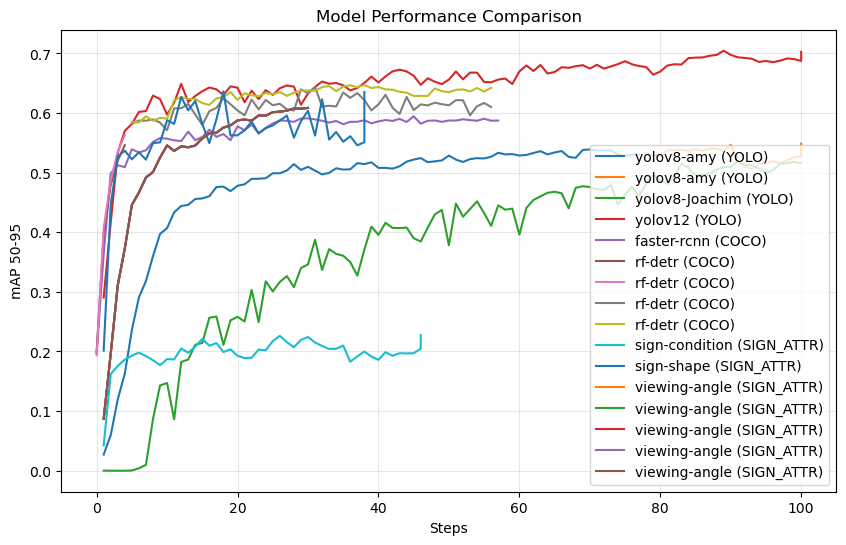

Total DataFrames processed: 14
Missing DataFrames: 0
Total mAP50-95 headers found: 16
Unique mAP50-95 headers found: {'metrics_mAP50-95B', 'Metrics/EMA/AP50_90', 'Metrics/Base/AP50_90', 'metrics/mAP50-95(B)', 'metrics/mAP50-95_B_'}


In [9]:
plt.figure(figsize=(10, 6))


# useful stats
stats_dict = {
    'missing_dfs': 0,
    'total_dfs': 0,
    'mAP50-95_headers': set(),
    'map50-95_header_count': 0
}

for df in dataframes_list:
    stats_dict['total_dfs'] += 1
    if df.empty: # because not everyone pushed yet
        stats_dict['missing_dfs'] += 1
        continue

    headers = df['metric'].unique()
    for header in headers:
        if 'AP' in header and '50' in header and '9' in header:
            stats_dict['mAP50-95_headers'].add(header)
            stats_dict['map50-95_header_count'] += 1
            
            # for the plot
            subset = df[df['metric'] == header]

            # Plot once per model/metric
            plt.plot(
                subset['step'],
                subset['value'],
                label=f"{df['model'].iloc[0]} ({df['category'].iloc[0]})"
            )

plt.xlabel('Steps')
plt.ylabel('mAP 50-95')
plt.title('Model Performance Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Total DataFrames processed: {stats_dict['total_dfs']}")
print(f"Missing DataFrames: {stats_dict['missing_dfs']}")
print(f"Total mAP50-95 headers found: {stats_dict['map50-95_header_count']}")
print(f"Unique mAP50-95 headers found: {stats_dict['mAP50-95_headers']}")

the results are a bit broken, lets try fix them

2 main issues: 
- overlapping results for the same plot -> how do we choose which one to keep
- one plot cut up into pieces -> can we join them

In [10]:
# we can use num dfs > 1 to detect issues
for model in model_groups.values():
    for name, df_list in model.items():
        if len(df_list) > 1:
            print(f'model: {name}, df count: {len(df_list)}') 
        
            # check if condition 1 or 2
            
            # condition 1: check if all dfs have overlapping epochs
            epochs_sets = [set(df['step'].unique()) for df in df_list]
            common_epochs = set.intersection(*epochs_sets)
            if common_epochs:
                print(f'  Condition 1 met: No overlapping epochs among DataFrames for model: {name}')
                continue # cant be both condition 1 & 2
            
            # condition 2: check if dfs have different epochs
            all_epochs = set().union(*epochs_sets)
            if len(all_epochs) == sum(len(epochs) for epochs in epochs_sets):
                print(f'  Condition 2 met: Different epochs among DataFrames for model: {name}')
            
            

model: yolov8-amy, df count: 2
  Condition 2 met: Different epochs among DataFrames for model: yolov8-amy
model: rf-detr, df count: 2
  Condition 2 met: Different epochs among DataFrames for model: rf-detr
model: viewing-angle, df count: 5
  Condition 1 met: No overlapping epochs among DataFrames for model: viewing-angle
